# Do recorded histories recover branch-specific $\omega$?

### A live R/PalantiR validation of the Goldman--Yang 1994 simulator

<div class="hero-note">
<strong>Result:</strong> PASS · 50 taxa · 5,000 codon sites · 762,540
recorded substitutions · synonymous scaling
</div>

This notebook constructs the complete branch-heterogeneous GY94 model in
**R**, simulates the alignment with the development checkout of
**PalantiR**, and analyzes the returned substitution-history object in the
same live session. It is both an executable feature demonstration and a
history-level validation of the simulator.


## tl;dr

* The left 25-taxon subtree was assigned $\omega=0.1$ and recovered
  **0.10002** from 167,553 synonymous and 38,818 nonsynonymous events.
* The right 25-taxon subtree was assigned $\omega=1.0$ and recovered
  **0.99104** from 168,766 synonymous and 387,403 nonsynonymous events.
* Raw nonsynonymous/synonymous event-count ratios were 0.23168 and 2.29550.
  They are **not** $d_N/d_S$: Goldman--Yang normalization must account for
  unequal synonymous and nonsynonymous opportunities.
* PalantiR's interactive alignment and history viewers below operate on the
  newly simulated objects, not pre-rendered screenshots or saved tables.


## Context & Methods

### 1. Load the PalantiR checkout

The first cell locates the repository from the notebook's working
directory, loads its R and compiled C++ code directly, and explicitly
selects the standard nuclear genetic code. No installed release of
PalantiR is required.


In [1]:
find_repository_root <- function(start = getwd()) {
    candidate <- normalizePath(start, mustWork = TRUE)
    repeat {
        if(file.exists(file.path(candidate, "DESCRIPTION")) &&
           dir.exists(file.path(candidate, "validation"))) {
            return(candidate)
        }
        parent <- dirname(candidate)
        if(identical(parent, candidate)) break
        candidate <- parent
    }
    stop("Could not locate the PalantiR repository root")
}

REPO_ROOT <- find_repository_root()
compiled_library <- file.path(
    REPO_ROOT, "src", paste0("Palantir", .Platform$dynlib.ext))
pkgload::load_all(
    REPO_ROOT,
    compile = !file.exists(compiled_library),
    quiet = TRUE
)
use_genetic_code("Standard nuclear")

LIVE_DIR <- file.path(REPO_ROOT, "runs", "gy94-deep-tree-live-notebook")
FIGURE_DIR <- file.path(LIVE_DIR, "notebook_figures")
dir.create(FIGURE_DIR, recursive = TRUE, showWarnings = FALSE)

options(
    digits = 7,
    repr.plot.width = 9.5,
    repr.plot.height = 5.5,
    repr.plot.res = 120
)

BLUE <- "#2563EB"
GOLD <- "#D97706"
INK <- "#172033"
MUTED <- "#667085"
GRID <- "#D9DEE7"
MODE_COLOR <- c(`0` = BLUE, `1` = GOLD)

IRdisplay::display_html('
<style>
  .hero-note, .pass-note, .scope-note {
    border-left: 5px solid #2563EB; background: #F4F7FC;
    padding: 0.8rem 1rem; margin: 0.8rem 0 1.2rem; border-radius: 3px;
  }
  .pass-note { border-left-color: #1F7A5A; background: #F1F8F5; }
  .scope-note { border-left-color: #D97706; background: #FFF8EC; }
</style>')

cat("Repository:       ", basename(REPO_ROOT), "\n", sep = "")
cat("PalantiR version: ", as.character(packageVersion("PalantiR")), "\n", sep = "")
cat("R version:        ", R.version.string, "\n", sep = "")
cat("Genetic code:     ", get_genetic_code(), " (", length(GeneticCode()),
    " sense codons)\n", sep = "")


Repository:       palantir_pub


PalantiR version: 1.3.0


R version:        R version 4.5.1 (2025-06-13)


Genetic code:     Standard nuclear (61 sense codons)


### 2. Define the experiment

The test uses a fully bifurcating 50-taxon tree. Each root-to-tip path has
depth 20 in synonymous-scaled branch units. The two 25-tip subtrees share
$\kappa=4$ and one mildly imbalanced F1x4 equilibrium, but use different
values of $\omega$.

#### Key assumptions

* Under `scaling_type = "synonymous"`, one branch-length unit is one
  expected synonymous substitution per codon at stationarity.
* Root codons are sampled from the equilibrium shared by both branch modes,
  so this test contains no equilibrium-frequency transient.
* Sites are independent simulation replicates; events on branches within a
  site are not treated as independent Poisson observations.


In [2]:
n_sites <- 5000L
seed <- 20260825L
kappa <- 4
omega <- c(`0` = 0.1, `1` = 1.0)
nucleotide_frequencies <- c(T = 0.22, C = 0.28, A = 0.27, G = 0.23)
root_to_tip_depth <- 20
basal_stem <- 19
crown_depth <- root_to_tip_depth - basal_stem
internal_edge <- 0.15

data.frame(
    parameter = c("Taxa", "Codon sites", "Root-to-tip depth", "Kappa",
                  "F1x4 frequencies", "Left subtree", "Right subtree", "RNG seed"),
    value = c("50 (25 + 25)", format(n_sites, big.mark = ","),
              "20 synonymous-scaled units", kappa,
              "T=0.22, C=0.28, A=0.27, G=0.23",
              "omega=0.1", "omega=1.0", seed),
    check.names = FALSE
)


parameter,value
<chr>,<chr>
Taxa,50 (25 + 25)
Codon sites,"5,000"
Root-to-tip depth,20 synonymous-scaled units
Kappa,4
F1x4 frequencies,"T=0.22, C=0.28, A=0.27, G=0.23"
Left subtree,omega=0.1
Right subtree,omega=1.0
RNG seed,20260825


### 3. Construct the tree and branch-mode tree

The topology is generated deterministically. The long basal stems make the
test deep while keeping the fully recorded event history tractable.
PalantiR's mode tree assigns every branch in the left clade to model 0 and
every branch in the right clade to model 1.


In [3]:
render_clade <- function(labels, mode, depth = 0) {
    if(length(labels) < 2L) stop("render_clade requires at least two labels")
    split_at <- floor(length(labels) / 2L)
    groups <- list(labels[seq_len(split_at)], labels[-seq_len(split_at)])

    render_child <- function(group) {
        if(length(group) == 1L) {
            terminal <- crown_depth - depth
            if(terminal <= 0) stop("Crown construction exhausted its depth")
            return(list(
                tree = sprintf("%s:%.15g", group, terminal),
                modes = sprintf("%s:%d", group, mode)
            ))
        }
        child <- render_clade(group, mode, depth + internal_edge)
        list(
            tree = sprintf("%s:%.15g", child$tree, internal_edge),
            modes = sprintf("%s:%d", child$modes, mode)
        )
    }

    children <- lapply(groups, render_child)
    list(
        tree = sprintf("(%s,%s)", children[[1]]$tree, children[[2]]$tree),
        modes = sprintf("(%s,%s)", children[[1]]$modes, children[[2]]$modes)
    )
}

left <- render_clade(sprintf("L%02d", seq_len(25L)), mode = 0L)
right <- render_clade(sprintf("R%02d", seq_len(25L)), mode = 1L)
tree_newick <- sprintf("(%s:%.15g,%s:%.15g);",
                       left$tree, basal_stem, right$tree, basal_stem)
mode_newick <- sprintf("(%s:0,%s:1);", left$modes, right$modes)

tree_path <- file.path(LIVE_DIR, "tree_50_taxa_depth20.newick")
mode_path <- file.path(LIVE_DIR, "mode_tree_left_omega0.1_right_omega1.newick")
writeLines(tree_newick, tree_path)
writeLines(mode_newick, mode_path)

tree <- Phylogeny(tree_path)
mode_tree <- Phylogeny(mode_path, type = "mode")
branch_table <- phylogeny_to_intervals(tree, mode_tree)
branch_table$branch_length <- branch_table$to - branch_table$from
branch_table$subtree <- ifelse(branch_table$state == 0,
                               "left_omega_0.1", "right_omega_1.0")

stopifnot(nrow(branch_table) == 98L,
          length(unique(branch_table$node)) == 98L,
          identical(as.integer(table(branch_table$state)), c(49L, 49L)))

data.frame(
    subtree = c("left: omega=0.1", "right: omega=1.0"),
    branches = as.integer(table(branch_table$state)),
    total_branch_length = as.numeric(tapply(
        branch_table$branch_length, branch_table$state, sum))
)


subtree,branches,total_branch_length
<chr>,<int>,<dbl>
left: omega=0.1,49,33.5
right: omega=1.0,49,33.5


### 4. Construct the GY94 process

These are the exact objects passed to PalantiR's simulator. Because this is
a single site class, mixture-wide and component scaling coincide; the two
branch modes differ only in $\omega$.


In [4]:
pi_codon <- F1x4(nucleotide_frequencies)
branch_process <- GY94BranchModel(
    models = list(
        GY94(omega = omega[["0"]], kappa = kappa,
             frequencies = pi_codon, scaling_type = "synonymous"),
        GY94(omega = omega[["1"]], kappa = kappa,
             frequencies = pi_codon, scaling_type = "synonymous")
    ),
    mode_phylogeny = mode_tree,
    start_mode = 0L
)
site_model <- GY94SiteModel(
    list(branch_process = branch_process),
    n_sites = n_sites
)

genetic_code <- GeneticCode()
codons <- names(genetic_code)
amino_acids <- unname(genetic_code)
codon_chars <- strsplit(codons, "")
one_step <- outer(seq_along(codons), seq_along(codons),
                  Vectorize(function(i, j) {
                      i != j && sum(codon_chars[[i]] != codon_chars[[j]]) == 1L
                  }))
same_amino_acid <- outer(amino_acids, amino_acids, "==")
synonymous_mask <- one_step & same_amino_acid
nonsynonymous_mask <- one_step & !same_amino_acid

stationary_flux <- function(model, mask) {
    sum(as.numeric(model$equilibrium) * rowSums(model$transition * mask))
}

neutral <- GY94(omega = 1, kappa = kappa, frequencies = pi_codon,
                scaling_type = "standard")
rS0 <- stationary_flux(neutral, synonymous_mask)
rN0 <- stationary_flux(neutral, nonsynonymous_mask)
S_sites <- 3 * rS0 / (rS0 + rN0)
N_sites <- 3 * rN0 / (rS0 + rN0)

effective_models <- site_model$models[[1]]$models
matrix_rates <- do.call(rbind, lapply(seq_along(effective_models), function(i) {
    model <- effective_models[[i]]
    data.frame(
        mode = i - 1L,
        assigned_omega = omega[[as.character(i - 1L)]],
        synonymous_rate = stationary_flux(model, synonymous_mask),
        nonsynonymous_rate = stationary_flux(model, nonsynonymous_mask),
        total_rate = stationary_flux(model, synonymous_mask | nonsynonymous_mask)
    )
}))

stopifnot(abs(S_sites + N_sites - 3) < 2e-12,
          all(abs(matrix_rates$synonymous_rate - 1) < 1e-11))

list(
    Goldman_Yang_sites_per_codon = c(synonymous = S_sites,
                                     nonsynonymous = N_sites),
    effective_matrix_rates = matrix_rates
)


mode,assigned_omega,synonymous_rate,nonsynonymous_rate,total_rate
<int>,<dbl>,<dbl>,<dbl>,<dbl>
0,0.1,1,0.2316261,1.231626
1,1.0,1,2.3162606,3.316261


## Data

### 5. Simulate the alignment and complete history

The next cell calls `simulate_gy94_site_model()` directly. Both R and
PalantiR's compiled simulator are seeded, so rerunning the notebook from a
clean kernel reproduces the same alignment and history.


In [5]:
set.seed(seed)
set_palantir_seed(seed)

started <- proc.time()[["elapsed"]]
simulation <- simulate_gy94_site_model(
    tree,
    site_model,
    rescale_method = "exact"
)
elapsed_seconds <- proc.time()[["elapsed"]] - started

stopifnot(nrow(simulation$alignment) == 50L,
          ncol(simulation$alignment) == n_sites)

data.frame(
    object = c("alignment", "substitution history", "site classes"),
    dimensions = c(
        sprintf("%d taxa x %s codon sites", nrow(simulation$alignment),
                format(ncol(simulation$alignment), big.mark = ",")),
        sprintf("%s events x %d fields",
                format(nrow(simulation$substitutions), big.mark = ","),
                ncol(simulation$substitutions)),
        sprintf("%s sites x %d fields",
                format(nrow(simulation$site_classes), big.mark = ","),
                ncol(simulation$site_classes))
    ),
    stringsAsFactors = FALSE
)
cat(sprintf("\nSimulation completed in %.3f seconds.\n", elapsed_seconds))


object,dimensions
<chr>,<chr>
alignment,"50 taxa x 5,000 codon sites"
substitution history,"762,540 events x 13 fields"
site classes,"5,000 sites x 3 fields"



Simulation completed in 2.657 seconds.


In [6]:
history_preview_fields <- intersect(
    c("site", "node", "time", "codon_from", "codon_to",
      "amino_acid_from", "amino_acid_to", "synonymous",
      "site_class", "class_index"),
    names(simulation$substitutions)
)
head(simulation$substitutions[, history_preview_fields, drop = FALSE], 8)


,site,node,time,codon_from,codon_to,amino_acid_from,amino_acid_to,synonymous,site_class,class_index
,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<int>
1,0,1,0.9457172,CGG,CGA,R,R,TRUE,branch_process,0
2,0,1,1.2109172,CGA,AGA,R,R,TRUE,branch_process,0
3,0,1,3.3940610,AGA,CGA,R,R,TRUE,branch_process,0
4,0,1,5.0593898,CGA,CGG,R,R,TRUE,branch_process,0
5,0,1,5.1832145,CGG,GGG,R,G,FALSE,branch_process,0
6,0,1,5.7302892,GGG,GGC,G,G,TRUE,branch_process,0
7,0,1,7.1450516,GGC,GGT,G,G,TRUE,branch_process,0
8,0,1,9.1403766,GGT,GGC,G,G,TRUE,branch_process,0


### 6. Explore the newly simulated alignment

This is PalantiR's native interactive alignment widget, restricted to the
first 60 codon sites for readability. It is generated from
`simulation$alignment` in this kernel; hover and scroll behavior remain live
in JupyterLab.


In [7]:
plot(simulation$alignment[, seq_len(60L)])


HTML widgets cannot be represented in plain text (need html)

### Goldman--Yang normalization

Let $r_S^0$ and $r_N^0$ be the stationary synonymous and nonsynonymous
fluxes from the neutral ($\omega=1$) generator with the same $\kappa$ and
codon frequencies. Goldman and Yang's opportunity counts per codon are

$$
S=3\frac{r_S^0}{r_S^0+r_N^0}, \qquad
N=3\frac{r_N^0}{r_S^0+r_N^0}.
$$

For history counts $C_S$ and $C_N$ over $L$ simulated codons,

$$
d_S=\frac{C_S}{LS}, \qquad
d_N=\frac{C_N}{LN}, \qquad
\frac{d_N}{d_S}=\frac{C_N}{C_S}\frac{S}{N}.
$$

This is why the raw nonsynonymous/synonymous event-count ratio is not
$d_N/d_S$.


In [8]:
history <- simulation$substitutions
mode_by_node <- setNames(branch_table$state, as.character(branch_table$node))
history$mode <- unname(mode_by_node[as.character(history$node)])
history$subtree <- ifelse(history$mode == 0,
                          "left_omega_0.1", "right_omega_1.0")
stopifnot(!anyNA(history$mode))

per_site <- lapply(0:1, function(mode) {
    selected <- history$mode == mode
    data.frame(
        site = seq_len(n_sites) - 1L,
        mode = mode,
        subtree = if(mode == 0L) "left_omega_0.1" else "right_omega_1.0",
        synonymous_events = tabulate(
            history$site[selected & history$synonymous] + 1L,
            nbins = n_sites),
        nonsynonymous_events = tabulate(
            history$site[selected & !history$synonymous] + 1L,
            nbins = n_sites)
    )
})

summaries <- lapply(0:1, function(mode) {
    counts <- per_site[[mode + 1L]]
    C_S <- sum(counts$synonymous_events)
    C_N <- sum(counts$nonsynonymous_events)
    dS_by_site <- counts$synonymous_events / S_sites
    dN_by_site <- counts$nonsynonymous_events / N_sites
    empirical_ratio <- mean(dN_by_site) / mean(dS_by_site)

    influence <- (dN_by_site - empirical_ratio * dS_by_site) /
                 mean(dS_by_site)
    ratio_se <- sd(influence) / sqrt(n_sites)
    log_se <- ratio_se / empirical_ratio
    ratio_ci <- empirical_ratio * exp(
        c(-1, 1) * qnorm(0.975) * log_se)

    branches <- branch_table$state == mode
    total_branch_length <- sum(branch_table$branch_length[branches])
    exposure <- n_sites * total_branch_length
    model_rates <- matrix_rates[matrix_rates$mode == mode, ]

    data.frame(
        mode = mode,
        subtree = if(mode == 0L) "left_omega_0.1" else "right_omega_1.0",
        assigned_omega = omega[[as.character(mode)]],
        branches = sum(branches),
        total_branch_length = total_branch_length,
        synonymous_events = C_S,
        nonsynonymous_events = C_N,
        raw_n_over_s = C_N / C_S,
        expected_raw_n_over_s = omega[[as.character(mode)]] * rN0 / rS0,
        empirical_synonymous_rate = C_S / exposure,
        expected_synonymous_rate = model_rates$synonymous_rate,
        empirical_nonsynonymous_rate = C_N / exposure,
        expected_nonsynonymous_rate = model_rates$nonsynonymous_rate,
        empirical_dN_dS = empirical_ratio,
        dN_dS_sitewise_se = ratio_se,
        dN_dS_95pct_lower = ratio_ci[[1]],
        dN_dS_95pct_upper = ratio_ci[[2]],
        relative_error = empirical_ratio / omega[[as.character(mode)]] - 1
    )
})
summary_table <- do.call(rbind, summaries)


## Results

### 7. Reconcile the live simulation

These checks use the newly returned R objects. They verify tree assignment,
event totals, synonymous scaling, Goldman--Yang opportunity normalization,
and the fixed-seed history-derived estimates.


In [9]:
stopifnot(
    nrow(history) == 762540L,
    identical(summary_table$synonymous_events, c(167553L, 168766L)),
    identical(summary_table$nonsynonymous_events, c(38818L, 387403L)),
    max(abs(summary_table$empirical_dN_dS -
            c(0.100021539237410, 0.991038687601490))) < 1e-12,
    max(abs(summary_table$empirical_synonymous_rate - 1)) < 0.008
)

IRdisplay::display_html(paste0(
    '<div class="pass-note"><strong>PASS:</strong> the live PalantiR run produced ',
    format(nrow(history), big.mark = ","),
    ' recorded substitutions. Branch allocation, synonymous scaling, event ',
    'totals, and history-derived dN/dS all reconcile.</div>'
))

result_table <- data.frame(
    Subtree = c("Left: omega=0.1", "Right: omega=1.0"),
    `Assigned omega` = summary_table$assigned_omega,
    `Synonymous events` = format(summary_table$synonymous_events, big.mark = ","),
    `Nonsynonymous events` = format(summary_table$nonsynonymous_events, big.mark = ","),
    `Raw N/S` = sprintf("%.5f", summary_table$raw_n_over_s),
    `GY94 dN/dS` = sprintf("%.5f", summary_table$empirical_dN_dS),
    `95% interval` = sprintf("%.5f--%.5f",
                             summary_table$dN_dS_95pct_lower,
                             summary_table$dN_dS_95pct_upper),
    `Relative error` = sprintf("%+.3f%%", 100 * summary_table$relative_error),
    check.names = FALSE
)
result_table


PASS: the live PalantiR run produced 762,540 recorded substitutions. Branch allocation, synonymous scaling, event totals, and history-derived dN/dS all reconcile.

Subtree,Assigned omega,Synonymous events,Nonsynonymous events,Raw N/S,GY94 dN/dS,95% interval,Relative error
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Left: omega=0.1,0.1,"167,553","38,818",0.23168,0.10002,0.09872--0.10134,+0.022%
Right: omega=1.0,1.0,"168,766","387,403",2.29550,0.99104,0.98459--0.99753,-0.896%


### 8. Compare assigned and recovered $d_N/d_S$

Intervals use sites as independent replicates. The intent is to detect a
material generator or scaling failure, not to require one Monte Carlo
realization to equal its parameter exactly.


agg_record_1082022372 
                    2

agg_record_1082022372 
                    2

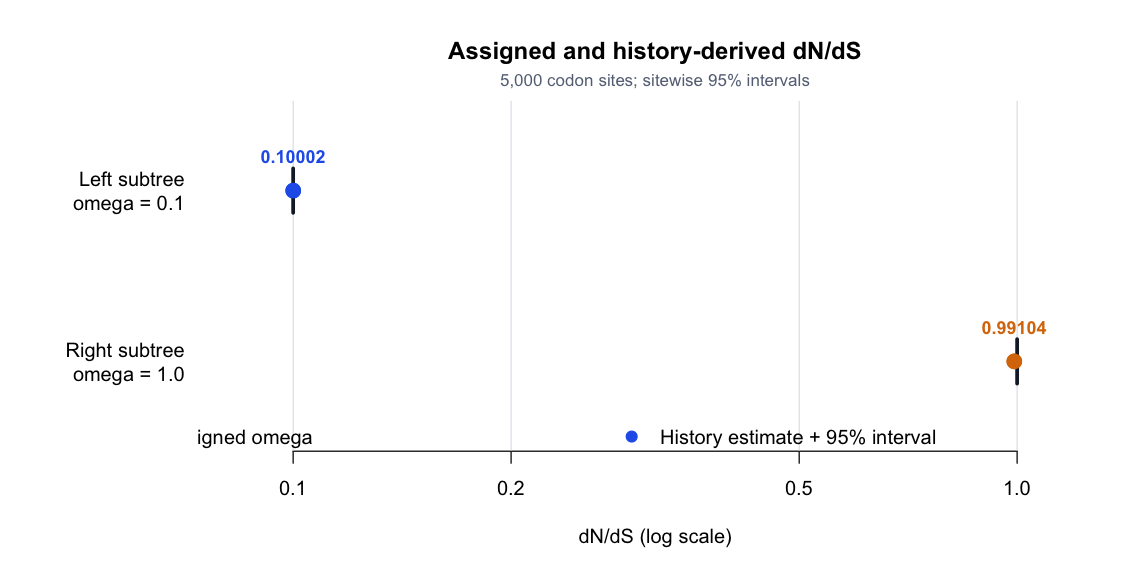

In [10]:
draw_calibration <- function() {
    rows <- summary_table[c(2, 1), ]
    y <- c(1, 2)
    colors <- MODE_COLOR[as.character(rows$mode)]
    par(mar = c(5.2, 8.2, 4.2, 1.1), las = 1, bg = "white")
    plot(rows$empirical_dN_dS, y,
         log = "x", xlim = c(0.082, 1.22), ylim = c(0.55, 2.45),
         xlab = "dN/dS (log scale)", ylab = "", yaxt = "n",
         pch = 21, bg = colors, col = colors, cex = 1.6,
         xaxt = "n", bty = "n", main = "Assigned and history-derived dN/dS")
    axis(1, at = c(0.1, 0.2, 0.5, 1.0), labels = c("0.1", "0.2", "0.5", "1.0"))
    axis(2, at = y,
         labels = c("Right subtree\nomega = 1.0", "Left subtree\nomega = 0.1"),
         tick = FALSE, line = -0.5)
    abline(v = c(0.1, 0.2, 0.5, 1.0), col = GRID, lwd = 0.8)
    segments(rows$dN_dS_95pct_lower, y,
             rows$dN_dS_95pct_upper, y, col = colors, lwd = 2)
    segments(rows$assigned_omega, y - 0.13,
             rows$assigned_omega, y + 0.13, col = INK, lwd = 3)
    points(rows$empirical_dN_dS, y, pch = 21, bg = colors,
           col = colors, cex = 1.6)
    text(rows$empirical_dN_dS, y + 0.20,
         labels = sprintf("%.5f", rows$empirical_dN_dS),
         col = colors, font = 2, cex = 0.9)
    mtext("5,000 codon sites; sitewise 95% intervals", side = 3,
          line = 0.45, col = MUTED, cex = 0.85)
    legend("bottomright",
           legend = c("Assigned omega", "History estimate + 95% interval"),
           pch = c(124, 21), pt.bg = c(NA, BLUE), col = c(INK, BLUE),
           pt.cex = c(1.5, 1.2), bty = "n", horiz = TRUE)
}

png(file.path(FIGURE_DIR, "gy94_history_calibration_R.png"),
    width = 1700, height = 850, res = 180)
draw_calibration()
dev.off()
svg(file.path(FIGURE_DIR, "gy94_history_calibration_R.svg"),
    width = 9.5, height = 4.8)
draw_calibration()
dev.off()

options(repr.plot.width = 9.5, repr.plot.height = 4.8)
draw_calibration()


The $\omega=0.1$ estimate differs from its target by only +0.022%. The
$\omega=1$ estimate is 0.896% below its target. With 5,000 independent
sites, this particular fixed-seed estimate lies just below 1; the practical
discrepancy remains less than one percent.


### 9. Inspect a complete substitution history

The representative site is selected objectively as the site whose four
counts—synonymous and nonsynonymous events in each subtree—are jointly
closest to their across-site medians. The following widget is PalantiR's
native history viewer operating directly on `simulation`.


In [11]:
count_features <- cbind(
    left_synonymous = per_site[[1]]$synonymous_events,
    left_nonsynonymous = per_site[[1]]$nonsynonymous_events,
    right_synonymous = per_site[[2]]$synonymous_events,
    right_nonsynonymous = per_site[[2]]$nonsynonymous_events
)
medians <- apply(count_features, 2, median)
scales <- apply(count_features, 2, sd)
representative_site <- which.min(rowSums(
    abs(sweep(count_features, 2, medians, "-")) /
    matrix(scales, nrow = n_sites, ncol = 4, byrow = TRUE)
)) - 1L
representative_events <- history[history$site == representative_site, ]

cat("Representative site (zero-based):", representative_site, "\n")
cat("Counts [left S, left N, right S, right N]:",
    paste(count_features[representative_site + 1L, ], collapse = ", "), "\n")
cat("Recorded events at this site:", nrow(representative_events), "\n")
head(representative_events[, history_preview_fields, drop = FALSE], 8)


Representative site (zero-based): 512 


Counts [left S, left N, right S, right N]: 36, 8, 34, 77 


Recorded events at this site: 155 


,site,node,time,codon_from,codon_to,amino_acid_from,amino_acid_to,synonymous,site_class,class_index
,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<int>
77836,512,1,0.2890747,CTA,CTC,L,L,TRUE,branch_process,0
77837,512,1,1.3995058,CTC,CTT,L,L,TRUE,branch_process,0
77838,512,1,4.3006110,CTT,CTC,L,L,TRUE,branch_process,0
77839,512,1,5.7224223,CTC,CTT,L,L,TRUE,branch_process,0
77840,512,1,6.0729792,CTT,CTC,L,L,TRUE,branch_process,0
77841,512,1,6.4606265,CTC,CTT,L,L,TRUE,branch_process,0
77842,512,1,6.9336235,CTT,CTC,L,L,TRUE,branch_process,0
77843,512,1,8.6893637,CTC,CTT,L,L,TRUE,branch_process,0


In [12]:
history_view <- simulation
history_view$substitutions <- representative_events
plot(history_view, sites = representative_site)


HTML widgets cannot be represented in plain text (need html)

For a publication-stable view, the next cell reconstructs the same site's
history from the PalantiR tree and event objects using base R graphics.
Open circles are synonymous events and filled triangles are nonsynonymous
events.


agg_record_1013940475 
                    2

agg_record_1013940475 
                    2

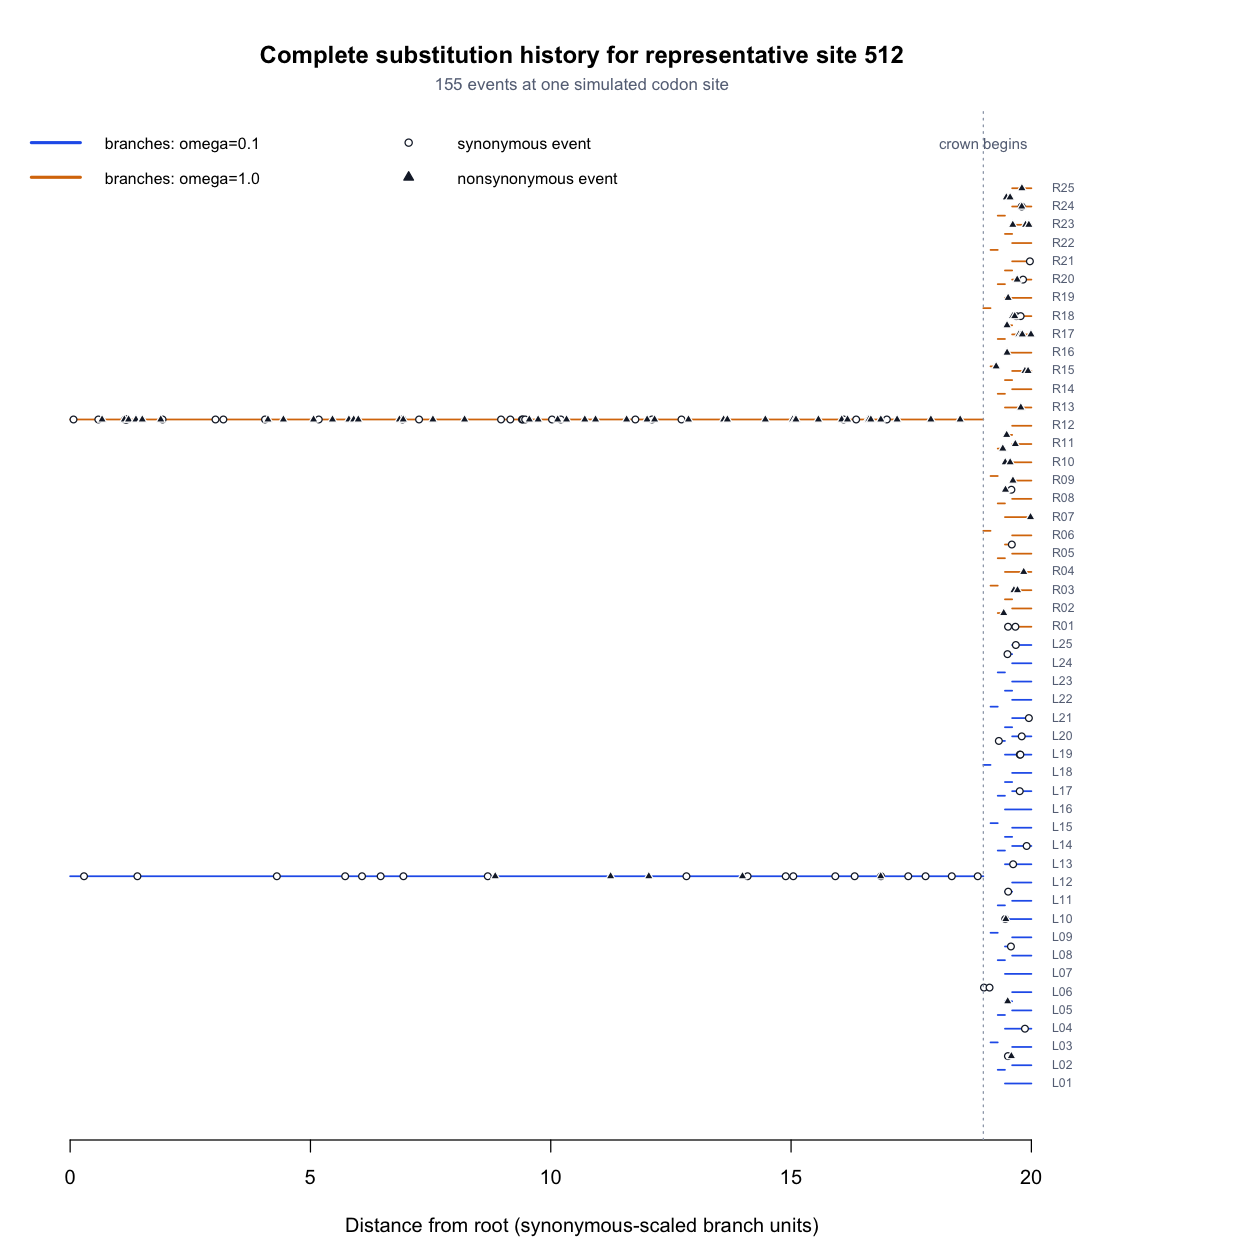

In [13]:
tree_root <- jsonlite::fromJSON(tree$json, simplifyVector = FALSE)
node_rows <- list()
leaf_counter <- 0L

walk_tree <- function(node, parent = NA_integer_, depth = 0) {
    node_index <- as.integer(node$index)
    children <- node$children
    is_leaf <- is.null(children) || length(children) == 0L
    if(is_leaf) {
        y <- leaf_counter
        leaf_counter <<- leaf_counter + 1L
    } else {
        child_y <- vapply(children, function(child) {
            walk_tree(child, node_index, depth + as.numeric(child$length))
        }, numeric(1))
        y <- mean(child_y)
    }
    node_rows[[as.character(node_index)]] <<- data.frame(
        index = node_index,
        parent = parent,
        depth = depth,
        y = y,
        label = as.character(node$label),
        is_leaf = is_leaf,
        stringsAsFactors = FALSE
    )
    y
}
invisible(walk_tree(tree_root))
node_table <- do.call(rbind, node_rows)
rownames(node_table) <- NULL
node_table <- node_table[order(node_table$index), ]
node_table$parent_depth <- node_table$depth[
    match(node_table$parent, node_table$index)]

stopifnot(nrow(node_table) == 99L,
          sum(!node_table$index %in% branch_table$node) == 1L,
          all(abs(node_table$depth[node_table$is_leaf] - 20) < 1e-10))

draw_representative_history <- function() {
    par(mar = c(5, 1, 4.5, 5), bg = "white")
    plot(NA, xlim = c(-0.1, 21.4), ylim = c(-1, 51.3),
         xlab = "Distance from root (synonymous-scaled branch units)",
         ylab = "", yaxt = "n", bty = "n",
         main = sprintf("Complete substitution history for representative site %d",
                        representative_site))

    for(parent_index in node_table$index) {
        children <- node_table[node_table$parent == parent_index, ]
        if(nrow(children) > 1L) {
            parent_depth <- node_table$depth[node_table$index == parent_index]
            segments(parent_depth, min(children$y), parent_depth, max(children$y),
                     col = "#C7CED9", lwd = 0.8)
        }
    }
    for(i in seq_len(nrow(node_table))) {
        node <- node_table[i, ]
        if(is.na(node$parent)) next
        mode <- branch_table$state[match(node$index, branch_table$node)]
        segments(node$parent_depth, node$y, node$depth, node$y,
                 col = MODE_COLOR[as.character(mode)], lwd = 1.4)
    }

    event_nodes <- match(representative_events$node, node_table$index)
    event_x <- node_table$parent_depth[event_nodes] + representative_events$time
    event_y <- node_table$y[event_nodes]
    is_syn <- representative_events$synonymous
    points(event_x[is_syn], event_y[is_syn], pch = 21, bg = "white",
           col = INK, cex = 0.75)
    points(event_x[!is_syn], event_y[!is_syn], pch = 24, bg = INK,
           col = "white", cex = 0.75)

    leaves <- node_table[node_table$is_leaf, ]
    text(20.18, leaves$y, labels = leaves$label, pos = 4,
         cex = 0.62, col = MUTED, xpd = TRUE)
    abline(v = 19, col = "#98A2B3", lty = 3)
    text(19, 50.5, "crown begins", pos = 3, cex = 0.75, col = MUTED)
    legend("topleft",
           legend = c("branches: omega=0.1", "branches: omega=1.0",
                      "synonymous event", "nonsynonymous event"),
           col = c(BLUE, GOLD, INK, INK),
           lty = c(1, 1, NA, NA), lwd = c(2.5, 2.5, NA, NA),
           pch = c(NA, NA, 21, 24), pt.bg = c(NA, NA, "white", INK),
           bty = "n", ncol = 2, cex = 0.8)
    mtext(sprintf("%d events at one simulated codon site",
                  nrow(representative_events)), side = 3,
          line = 0.55, col = MUTED, cex = 0.85)
}

png(file.path(FIGURE_DIR, "gy94_representative_site_history_R.png"),
    width = 1900, height = 1900, res = 180)
draw_representative_history()
dev.off()
svg(file.path(FIGURE_DIR, "gy94_representative_site_history_R.svg"),
    width = 10.5, height = 10.5)
draw_representative_history()
dev.off()

options(repr.plot.width = 10.5, repr.plot.height = 10.5)
draw_representative_history()


### 10. Examine across-site event counts

Each point is one codon site summarized across all 49 branches in one
subtree. Crosses show stationary expectations calculated from the exact
matrices and total branch exposure.


agg_record_1399284532 
                    2

agg_record_1399284532 
                    2

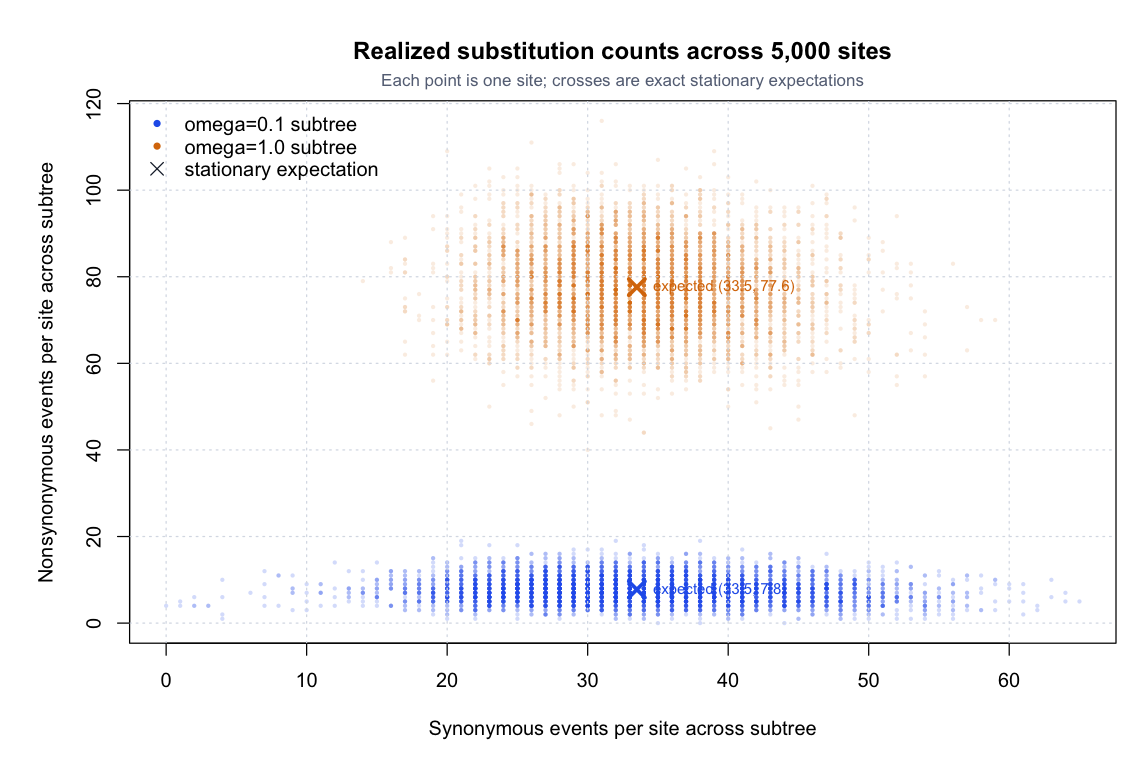

In [14]:
draw_site_counts <- function() {
    left_counts <- per_site[[1]]
    right_counts <- per_site[[2]]
    xlim <- range(c(left_counts$synonymous_events,
                    right_counts$synonymous_events))
    ylim <- range(c(left_counts$nonsynonymous_events,
                    right_counts$nonsynonymous_events))
    par(mar = c(5.2, 5.4, 4.2, 1), bg = "white")
    plot(left_counts$synonymous_events, left_counts$nonsynonymous_events,
         pch = 16, cex = 0.48, col = adjustcolor(BLUE, alpha.f = 0.20),
         xlim = xlim, ylim = ylim,
         xlab = "Synonymous events per site across subtree",
         ylab = "Nonsynonymous events per site across subtree",
         main = "Realized substitution counts across 5,000 sites")
    points(right_counts$synonymous_events, right_counts$nonsynonymous_events,
           pch = 16, cex = 0.48, col = adjustcolor(GOLD, alpha.f = 0.13))
    grid(col = GRID)

    expected <- do.call(rbind, lapply(0:1, function(mode) {
        branch_length <- sum(branch_table$branch_length[branch_table$state == mode])
        rates <- matrix_rates[matrix_rates$mode == mode, ]
        data.frame(
            x = branch_length * rates$synonymous_rate,
            y = branch_length * rates$nonsynonymous_rate,
            mode = mode
        )
    }))
    points(expected$x, expected$y, pch = 4,
           col = MODE_COLOR[as.character(expected$mode)], cex = 1.8, lwd = 3)
    text(expected$x, expected$y,
         labels = sprintf(" expected (%.1f, %.1f)", expected$x, expected$y),
         pos = 4, col = MODE_COLOR[as.character(expected$mode)], cex = 0.75)
    legend("topleft", legend = c("omega=0.1 subtree", "omega=1.0 subtree",
                                 "stationary expectation"),
           pch = c(16, 16, 4), col = c(BLUE, GOLD, INK),
           pt.cex = c(0.8, 0.8, 1.4), bty = "n")
    mtext("Each point is one site; crosses are exact stationary expectations",
          side = 3, line = 0.45, col = MUTED, cex = 0.85)
}

png(file.path(FIGURE_DIR, "gy94_per_site_event_counts_R.png"),
    width = 1700, height = 1150, res = 180)
draw_site_counts()
dev.off()
svg(file.path(FIGURE_DIR, "gy94_per_site_event_counts_R.svg"),
    width = 9.5, height = 6.4)
draw_site_counts()
dev.off()

options(repr.plot.width = 9.5, repr.plot.height = 6.4)
draw_site_counts()


## Takeaways

1. **Branch assignment works.** All 49 branches in each principal subtree
   use the intended GY94 process.
2. **Synonymous scaling retains its meaning.** The realized synonymous
   rates are 1.00032 and 1.00756 per codon-branch unit, close to the exact
   stationary target of 1.
3. **The recorded histories recover $\omega$.** Opportunity-normalized
   estimates are 0.10002 and 0.99104 for assigned values 0.1 and 1.0.
4. **Raw N/S is not $d_N/d_S$.** Correct normalization uses the synonymous
   and nonsynonymous opportunities implied by the genetic code, equilibrium
   frequencies, and $\kappa$.
5. **PalantiR's live objects are auditable.** The alignment, site-class
   metadata, complete events, event times, branch modes, and interactive
   viewers all remain available for further exploration in this kernel.

<div class="scope-note">
<strong>Scope:</strong> this is a stationary-frequency, single-site-class
GY94 demonstration. It validates this generator, branch heterogeneity,
history recording, and synonymous scaling. It is not by itself a validation
of every site-mixture, branch-site, transient-frequency, or inference
configuration.
</div>

### References

* Goldman N, Yang Z. 1994. A codon-based model of nucleotide substitution
  for protein-coding DNA sequences. *Molecular Biology and Evolution*
  11:725–736.
  [doi:10.1093/oxfordjournals.molbev.a040153](https://doi.org/10.1093/oxfordjournals.molbev.a040153)
* Yang Z. PAML source implementation, `eigenQcodon()` in
  [`codeml.c`](https://github.com/abacus-gene/paml/blob/master/src/codeml.c).
* The separately preserved
  [`gy94_deep_tree_history_dnds.ipynb`](gy94_deep_tree_history_dnds.ipynb)
  independently audits the committed production artifact in Python.
